<h1 style="text-align: center;">ANÁLISIS Y PROCESAMIENTO DE SEÑALES</h1>

<center>
    
### 1er cuatrimestre 2026
</center>

<p style="text-align: center;">Muñoz Jazmín Ayelén</p>

<h3 style="text-align;">INTRODUCCIÓN</h3>

En esta tarea semanal, se busca analizar el comportamiento de estimadores de amplitud y frecuencia, para una señal senoidal discreta, donde además, se le suma ruido blanco Gaussiano (AWGN). Posteriormente, se observa el impacto que tienen las distintas funciones de ventaneo sobre la precisión de la DTFT, todo esto contextualizado en un entorno donde la frecuencia de la sñeal presenta incertidumbre. 

La señal que resulta de interés, se halla determinada por la siguiente expresión: 


$$x(k) = a_0 \cdot \sin(\Omega_1 \cdot n) + n_a(n)$$

Donde $$a_0 = \sqrt{2}$$

Y donde además la frecuencia $\Omega_1$ , no es un parámetro fijo, sino que oscila de manera aleatoria alrededor de  un valor central $\Omega_0 = \pi/2$ , debido a la variable  $f_r$ la cual tiene una distribución uniforme entre el (-2;2). Dicha oscilación introduce el fenómeno ya hablado en la TS anterior, el desparramo espectral, debido a que la señal rara vez coincidirá exactamente con los bins de la FFT. La relación de $\Omega_1$  con $f_r$ puede verse a continuación en la siguiente expresión:

$$\Omega_1 = \Omega_0 + f_r \cdot \frac{2\pi}{N}$$

<h6 style="text-align;">ESTIMADORES</h6>

Un estimador es una función matemática que se aplica a los datos observados, en este caso a  la señal ruidosa $x(k)$ para realizar una inferencia sobre los valores reales de los parámetros del sistema, en palabras más simples, es lo que se le aplica a los datos de la señal para intentar rescatar los valores originales de amplitud y frecuencia. 

Sin embargo, en el marco de esta tarea, debido a que la señal del enunciado tiene ruido y además se ve afectada por el ventaneo, el estimador no dará el valor exacto, sino una aproximación de la amplitud $a_0$ y la frecuencia $\Omega_1$, dicha aproximación se denotará con el símbolo "sombrero". La calidad de estos estimadores se mide por su capacidad para aproximarse al valor real de manera repetitiva, lo cual se analizará mediante el cálculo de su sesgo , exactitud,  y su varianza, precisión.

<h6 style="text-align;">SESGO</h6> 

Representa el error sistemático del estimador, indica qué tan alejado está el promedio de las estimaciones respecto al valor real. 
Si el sesgo es cero, se dice que el estimador es "insesgado", o sea que en promedio  "le pega" al centro.

$$s_a = E\{\hat{a}_1\} - a_0$$

<h6 style="text-align;">VARIANZA</h6> 

La varianza ya no mide si se "le pegó" o no al centro, sino que se enfoca en ver qué tan dispersos entre sí están los valores obtenidos en cada realización, si por ejemplo, siempre se obtiene un valor en torno al 200, es decir 202, 201, 200 la varianza es baja, aunque el valor esté sesgado debido a que el valor real supuesto es 300. 

Si el ruido es alto, la varianza aumentará, pues cada vez que se realice una medición, el ruido será diferente y por lo tanto, también variará el resultdo obtenido respecto a la realización anterior.

$$v_a = E\{(\hat{a}_1 - E\{\hat{a}_1\})^2\}$$

Donde $E\{\cdot\}$ representa el valor esperado, en esta tarea semanal, coincide con el promedio de las 200 realizaciones.

<h3 style="text-align;">CONSIGNA</h3>

Para recuperar la información de la señal, se pide diseñae dos estimadores:

1. Estimador de Amplitud, evaluado puntualmente en la frecuencia $\Omega_0$ : 

$$\hat{a}_{i1} = |X_{iw}(\Omega_0)| = |\mathcal{F}\{x(n) \cdot w_i(n)\}|$$

2. Estimador de Frecuencia  $\Omega_1$: Basado en la búsqueda del máximo en el espectro.

$$\hat{\Omega}_{i1} = \arg \max_{f} \{|X_{iw}(\Omega)|\}$$

Para cada una de las ventanas:

- Rectangular (sin ventana), 
- Flattop 
- Blackmanharris
- Otra que se elija de scipy.signal.windows

<h3 style="text-align;">RESOLUCIÓN</h3>

In [4]:
import numpy as np
import matplotlib.pyplot as plt
# Importo el módulo específico de scipy que tiene las funciones de las ventanas
from scipy.signal import windows

# -------------------------------------------------GENERACIÓN DE LA SEÑAL-----------------------------------------------------------#

N = 1000  
R = 200   # Defino la cantidad de realizaciones, o sea cuántas señales distintas voy a simular.
fs = 1000 
ts = 1/fs 

# La consigna dice Omega_0 = pi/2. 

omega_0 = fs / 4  #Ya que fs/2 es Pi, N/2 y entonces pi/2.

# Fijo una "semilla" aleatoria. Esto hace que los números al azar  sean siempre los mismos cada vez que corro el código.
np.random.seed(42) #Le meto cualquier valor.

# Genero un vector columna con números aleatorios entre -2 y 2. Esta es mi variable fr.
fr = np.random.uniform(-2, 2, R).reshape((R, 1)) #Con el reshape lo obligo a que tenga 200x1

# Calculo la frecuencia real, usando la fórmula del campus omega0+fr*resolución espectral.
omega_1 = omega_0 + fr * (fs / N)

# Agarro ese vector de 200 frecuencias y lo repito 1000 veces hacia la derecha para armar una matriz.
omega = np.tile(omega_1, N)

# Creo un vector de tiempo que va desde 0 hasta (N-1)*ts. Lo armo como un vector fila.
tt = (np.arange(0, N) * ts).reshape((1, N))
#Nuevamente, lo repito con 
nn = np.tile(tt, (R, 1)) # Agarro mi vector fila de tiempo y lo repito 200 veces hacia abajo.


# --------------------------------DEFINO MI PARÁMETRO DE SNR PORQUE LA CONSIGNA ME PIDE QUE DESPUÉS LO CAMBIE. -------------------------------------#
 
SNR = 10  # Defino el SNR en dB ESTO DESPUÉS LO CAMBIO PARA EL 3dB

# La señal tiene potencia de 1 Watts, porque su amplitud, es a0. 
# Despejo la desviación estándar del ruido.
sigma = 10**(-SNR / 20)
mu = 0 # Media del ruido, la consigna me dice que es 0. 

# Genero una matriz gigante de ruido.
na = np.random.normal(mu, sigma, (R, N))
# Ahora aplico la fórmula de la senoidal (amplitud * seno(2*pi*f*t)) + el ruido.
xx = np.sqrt(2) * np.sin(np.pi * 2 * omega * nn) + na
# plt.plot(xx.T) #El profe dijo que la transponga, acá veo que efectivamente son muchas senoidales, lo uso como checkpoint. 

#---------------------------------------- CONFIGURO LOS ESTIMADORES Y LA  FFT----------------------------------------------------------##

# Busco el bin (la posición) que corresponde a omega_0. 
# Como omega_0 es fs/4, caerá en N/4.
bin_objetivo = int(omega_0 * N / fs) 

<h5 style="text-align;">CASO 1: A. VENTANA RECTANGULAR A 10dB de ruido </h5>

In [5]:
#%% EXPERIMENTO 1: VENTANA RECTANGULAR - SIN NADITA- 

ven_rect = np.ones(N) # La ventana rectangular es un vector lleno de unos.
xx_rect = xx * ven_rect # Hago la multiplicación de mi matriz de señales por la ventana.

X_rect = np.fft.fft(xx_rect, axis=1) # El axis me lo multiplica horizontalmente

# ESTIMADOR DE AMPLITUD:
    
# Busco el módulo de la FFT, normalizo por N y multiplico por 2 (por ser espectro unilateral).
# Lo evalúo solo en el bin_objetivo para todas las realizaciones.
amp_rect = (np.abs(X_rect[:, bin_objetivo]) / N) * 2 

# El sesgo es el promedio de mis estimaciones menos el valor real que yo sé que tiene que dar (raíz de 2).
sa_rect = np.mean(amp_rect) - np.sqrt(2) 

# Ahora calculo la varianza
var_rect = np.var(amp_rect)


# ESTIMADOR DE FRECUENCIA:

# Busco el bin de valor máximo para cada realización (estimación por máxima energía)
bin_maximo = np.argmax(np.abs(X_rect[:, :N//2]), axis=1)
# Convierto ese bin a Hz: frec = bin * fs / N
frec_estimada = bin_maximo * (fs / N)

# El sesgo es el promedio de la diferencia entre lo estimado y la frecuencia real omega_1.
sf_rect = np.mean(frec_estimada - omega_1.flatten())

# Ahora calculo la varianza del estimador de frecuencia
varf_rect = np.var(frec_estimada)

# ////////////////////////7 IMPRIMO LOS RESULTADOS ///////////////////
print("RESULTADOS PARA SNR = 10 dB")
print("\nESTIMADOR DE AMPLITUD (el Valor Ideal es = 1.4142)")
print("Rectangular - Varianza:", var_rect, "Sesgo:", sa_rect)
# Imprimo el estimador de amplitud (la media de las realizaciones)
print("Amplitud promedio estimada:", np.mean(amp_rect))

print("\nESTIMADOR DE FRECUENCIA")
print("Rectangular - Varianza:", varf_rect, "Sesgo:", sf_rect)

RESULTADOS PARA SNR = 10 dB

ESTIMADOR DE AMPLITUD (el Valor Ideal es = 1.4142)
Rectangular - Varianza: 0.18753049256207194 Sesgo: -0.9377666784902126
Amplitud promedio estimada: 0.4764468838828826

ESTIMADOR DE FRECUENCIA
Rectangular - Varianza: 1.6377750000000004 Sesgo: -0.02102493306646423


<h5 style="text-align;">CASO 1: B. VENTANA RECTANGULAR A 3dB de ruido </h5>

In [6]:
# --------------------------------DEFINO MI PARÁMETRO DE SNR PORQUE LA CONSIGNA ME PIDE QUE DESPUÉS LO CAMBIE. -------------------------------------#
 
SNR = 3  # Defino el SNR en 3dB
# La señal tiene potencia de 1 Watts, porque su amplitud, es a0. 
# Despejo la desviación estándar del ruido.
sigma = 10**(-SNR / 20)
mu = 0 # Media del ruido, la consigna me dice que es 0. 

# Genero una matriz gigante de ruido.
na = np.random.normal(mu, sigma, (R, N))
# Ahora aplico la fórmula de la senoidal (amplitud * seno(2*pi*f*t)) + el ruido.
xx3 = np.sqrt(2) * np.sin(np.pi * 2 * omega * nn) + na
# plt.plot(xx.T) #El profe dijo que la transponga, acá veo que efectivamente son muchas senoidales, lo uso como checkpoint. 

#---------------------------------------- CONFIGURO LOS ESTIMADORES Y LA  FFT----------------------------------------------------------##

# Busco el bin (la posición) que corresponde a omega_0. 
# Como omega_0 es fs/4, caerá en N/4.
bin_objetivo = int(omega_0 * N / fs) 
#%% EXPERIMENTO 1: VENTANA RECTANGULAR - SIN NADITA- 

ven_rect3 = np.ones(N) # La ventana rectangular es un vector lleno de unos.
xx_rect3 = xx3 * ven_rect3 # Hago la multiplicación de mi matriz de señales por la ventana.

X_rect3 = np.fft.fft(xx_rect3, axis=1) # El axis me lo multiplica horizontalmente

# ESTIMADOR DE AMPLITUD:
    
# Busco el módulo de la FFT, normalizo por N y multiplico por 2 (por ser espectro unilateral).
# Lo evalúo solo en el bin_objetivo para todas las realizaciones.
amp_rect3 = (np.abs(X_rect3[:, bin_objetivo]) / N) * 2 

# El sesgo es el promedio de mis estimaciones menos el valor real que yo sé que tiene que dar (raíz de 2).
sa_rect3 = np.mean(amp_rect3) - np.sqrt(2) 

# Ahora calculo la varianza
var_rect3 = np.var(amp_rect3)


# ESTIMADOR DE FRECUENCIA:

# Busco el bin de valor máximo para cada realización (estimación por máxima energía)
bin_maximo = np.argmax(np.abs(X_rect3[:, :N//2]), axis=1)
# Convierto ese bin a Hz: frec = bin * fs / N
frec_estimada = bin_maximo * (fs / N)

# El sesgo es el promedio de la diferencia entre lo estimado y la frecuencia real omega_1.
sf_rect3 = np.mean(frec_estimada - omega_1.flatten())

# Ahora calculo la varianza del estimador de frecuencia
varf_rect3 = np.var(frec_estimada)

# ////////////////////////7 IMPRIMO LOS RESULTADOS ///////////////////
print("RESULTADOS PARA SNR = 3 dB")
print("\nESTIMADOR DE AMPLITUD (el Valor Ideal es = 1.4142)")
print("Rectangular - Varianza:", var_rect3, "Sesgo:", sa_rect3)
# Imprimo el estimador de amplitud (la media de las realizaciones)
print("Amplitud promedio estimada:", np.mean(amp_rect3))

print("\nESTIMADOR DE FRECUENCIA")
print("Rectangular - Varianza:", varf_rect3, "Sesgo:", sf_rect3)

RESULTADOS PARA SNR = 3 dB

ESTIMADOR DE AMPLITUD (el Valor Ideal es = 1.4142)
Rectangular - Varianza: 0.18648294719611289 Sesgo: -0.9352555060341935
Amplitud promedio estimada: 0.47895805633890165

ESTIMADOR DE FRECUENCIA
Rectangular - Varianza: 1.6177750000000004 Sesgo: -0.02102493306646423


Al analizar los resultados obtenidos para la ventana rectangular, se observa un sesgo de amplitud negativo, de aproximadamente $-0.93$ , el estimador devuelve una media de $0.47$, alejándose considerablemente del valor esperado,  $a_0 = 1.414$. Esto ocurre debido a los altos lóbulos secundarios de la función sinc, que es el espectro de la ventana y a que la frecuencia $\Omega_1$ oscila por  $f_r$, produciendo que la señal casi nunca coincida con el bin medido ($\Omega_0$).

Por lo tanto, se produce el desparramo espectral de la energía, y el valor de la amplitud en el bin central decae, esto permite suponer que la ventana rectangular resulta insuficiente para estimar la amplitud de la señal, frente a la presencia de incertifumbre en la frecuencia.

Por su parte, el estimador de la frecuencia parece ser más eficiente, pues el sesgo es bajo, cercano a  $-0.01$ esto parecería indicar que el estimador es insesgado, la varianza de la frecuencia tiene un valor de aproximadamente $1.62$ , como la FFT actúa como rejilla con puntos fijos de 1Hz, porque así se definió en un principio, y siendo que la frecuencia real de la señal cae entre esos puntos, el estimador salta de un casillero a otro, es decir que se encuentra limitado por la resolución del bin, si se lo suavizara aumentando simbólicamente la resolución mediante la técnica de Zero-Padding, debería disminuir, esto se comprobará a medida que se avance en la resolución de las consignas de esta tarea. 

<h6 style="text-align;">ANÁLISIS SEÑAL 10dB vs 3dB</h6>

El sesgo de amplitud resulta casi idéntico en ambos casos, por lo que el error parecería ser estructural, la ventana rectangular tiene un lóbulo principal estrecho y frente a la mínima variación de frecuencia $\Omega_1$, la energía se desplaza, como ya mencionó previamente, por lo que el ruido no afecta al sesgo sino que se ve dominado por el  desparramiento espectral. 

La varianza de la amplitud presenta valores similares, esto no debería ser así, pero parece ocurrir debido a que la incertidumbre provocada por $f_r$ domina sobre la incertidumbre provocada por el ruido blanco.

<h5 style="text-align;">CASO 2: VENTANA FLATTOP  </h5>

La ventana flat-top es una función de ventaneo que busca eliminar el error de amplitud, es decir el scalloping loss del cual ya se habló en la TS anterior, este ocurre cuando la señal no cae exactamente en el un bin de la FFT. 

![IMAGEN DE LA VENTANA FLATOP EN EL TIEMPO.](flatop.jpg)

En el tiempo, tiene una forma con lóbulos negativos y cruces por cero, en el dominio de las frecuencias, su lóbulo principal es plano por lo que hay mayor probabilidad de que caiga en un bin y no se produzca el desparramo, sin embargo, para lograr esa cima plana sacrifica resolución.  Por lo tanto, al repetir el experimento con esta ventana, se esperaría que la varianza de la amplitud y su sesgo, disminuyeran de forma drástica. 

<h6 style="text-align;">A. SEÑAL  CON 10dB </h6>

In [7]:
ven_flat = windows.flattop(N) # Genero la ventana Flat-top usando scipy. 
s1_flat = np.sum(ven_flat) #Esta parte no sabía cómo hacerla, así que lo busqué, básicamente la FFT se achica mucho por esta ventana
#Antes todo era 1, pero ahora ya no, entonces necesito como recuperar ese peso que perdí al recortar, para que no em de una amplutd baja. 

# Aplico la ventana a mi matriz de 10 dB y calculo la FFT por filas con el axis=1.
xx_flat_10 = xx * ven_flat
X_flat_10 = np.fft.fft(xx_flat_10, axis=1)

# ESTIMADOR DE AMPLITUD 
# Evalúo en el bin_objetivo, normalizo por s1_flat y multiplico por 2.
amp_flat_10 = (np.abs(X_flat_10[:, bin_objetivo]) / s1_flat) * 2
sa_flat_10 = np.mean(amp_flat_10) - np.sqrt(2)
var_flat_10 = np.var(amp_flat_10)

# ESTIMADOR DE FRECUENCIA 
# Busco el máximo, paso a Hz y calculo sesgo, usando reshape para las dimensiones y varianza.
bin_max_flat_10 = np.argmax(np.abs(X_flat_10[:, :N//2]), axis=1)
frec_flat_10 = bin_max_flat_10 * (fs / N)
sf_flat_10 = np.mean(frec_flat_10 - omega_1.reshape(-1))
varf_flat_10 = np.var(frec_flat_10)

<h6 style="text-align;">A. SEÑAL  CON 3dB </h6>

In [8]:
# Hago exactamente lo mismo pero usando mi matriz 'xx3' que tiene más ruido.
xx_flat_3 = xx3 * ven_flat
X_flat_3 = np.fft.fft(xx_flat_3, axis=1)

# ESTIMADOR DE AMPLITUD
amp_flat_3 = (np.abs(X_flat_3[:, bin_objetivo]) / s1_flat) * 2
sa_flat_3 = np.mean(amp_flat_3) - np.sqrt(2)
var_flat_3 = np.var(amp_flat_3)

# ESTIMADOR DE FRECUENCIA
bin_max_flat_3 = np.argmax(np.abs(X_flat_3[:, :N//2]), axis=1)
frec_flat_3 = bin_max_flat_3 * (fs / N)
sf_flat_3 = np.mean(frec_flat_3 - omega_1.reshape(-1))
varf_flat_3 = np.var(frec_flat_3)


<h6 style="text-align;">RESUTADOS </h6>

In [9]:
print("================ RESULTADOS FLAT-TOP ================")
#Acá busqué formas de imprimir, porque si bien después quiero hacer una tabal comparativa, me estaba costando leer los resultados
#Así que le pasé a la guía esta aprte del código para que me la mejorara, dejo la versión anterior en la rectangular para tenert ambas
#formas de impresión. 
print("\n--- SNR = 10 dB ---") 
print(f"AMPLITUD   -> Promedio: {np.mean(amp_flat_10):.4f}, Sesgo: {sa_flat_10:.6f}, Varianza: {var_flat_10:.6e}") 
print(f"FRECUENCIA -> Sesgo: {sf_flat_10:.4f}, Varianza: {varf_flat_10:.4f}")

print("\n--- SNR = 3 dB ---")
print(f"AMPLITUD   -> Promedio: {np.mean(amp_flat_3):.4f}, Sesgo: {sa_flat_3:.6f}, Varianza: {var_flat_3:.6e}")
print(f"FRECUENCIA -> Sesgo: {sf_flat_3:.4f}, Varianza: {varf_flat_3:.4f}")

================ RESULTADOS FLAT-TOP ================

--- SNR = 10 dB ---
AMPLITUD   -> Promedio: 1.2926, Sesgo: -0.121659, Varianza: 2.157654e-02
FRECUENCIA -> Sesgo: 0.0040, Varianza: 1.5664

--- SNR = 3 dB ---
AMPLITUD   -> Promedio: 1.2882, Sesgo: -0.125991, Varianza: 2.723957e-02
FRECUENCIA -> Sesgo: 0.0190, Varianza: 1.5430


<h6 style="text-align;">ANÁLISIS </h6>

Al observar los resultados obtenidos para este caso, resulta visible la diferencia de amplitud promedio calculada entre esta ventana y la anterior. La rectangular rondaba en $0.47$, mientras que la flat-top dio un valor promedio de  $1.29$, asemejándose por mucho, al  valor esperado $a_0 = 1.414$, se puede afirmar entonces, que efectivamente se disminuyó el efecto del error en la amplitud producido por el leakege.

A su vez, el sesgo es visiblemente mejor, ya que disminuyó de $-0.93$ a $-0.12$, mientras que la varianza de amplitud pasó de $0.18$ a un valor en el orden de los centésimos ($0.02$). Además, la amplitud entre los 10dB y 3 dB es sumamente similar, parece ser que la flat-top "protegió" la amplitud frente a las variaciones de frecuencia y el aumento del ruido. 

Por último, la varianza de la frecuencia se mantuvo estable, esto resulta esperable, pues la flat-top no mejora la precisión en frecuencia, sino que se sigue condicionado a la resolución del bin de la FFT. 

<h5 style="text-align;">CASO 3: BLACKMANN - HARRIS  </h5>

Es una función de ventaneo de orden superior, o sea que se arma sumando varios cosenos, busca reducir al extremo los lóbulos secundarios, su espectro en el tiempo es una campana que cae suavemente en los extremos. 

![IMAGEN DE LA VENTANA BLACKMANN EN EL TIEMPO.](blackman.jpg)

En la frecuencia, sus lóbulos secundarios están muy atenuados llegando hasta más de $-90\text{ dB}$ , el ruido y las frecuencias lejanas al lóbulo principal no pueden desparramarse hacia los bines vecinos, por lo que el piso de ruido queda bastante limpio. Su lóbulo principal no es tan fino como el de la ventana rectangular pero es más angosto y menos plano que el de la flat-top. 

Al repetir el experimento, se espera obtener valores intermedios, al no tener una cima plana como la flat-top , el sesgo y la varianza de la amplitud crecerán, pero no deberían ser tan graves como en el caso de la rectangular. Debería tener una varianza estable frente al ruido, ya que al tener  lóbulos secundarios pequeñits, el ruido blanco de fondo no afecta tanto al lóbulo principal. 

Es una ventana intermedia,  no tiene tanta precisión de amplitud como la flat-top pero a cambio, posee mejor resolución espectral, lo que sirve si se tiene frecuencias cercanas que se desean distinguir.

<h6 style="text-align;">A. SEÑAL  CON 10dB </h6>

In [10]:
# Genero la ventana Blackman-Harris con scipy.
ven_blackman = windows.blackmanharris(N)
#Busco el factor s1 de nuevo, como en la anterior, porque esta también recorta. 
s1_blackman = np.sum(ven_blackman)

# Aplico la ventana a mi matriz de 10 dB y saco la FFT por filas.
xx_blackman_10 = xx * ven_blackman
X_blackman_10 = np.fft.fft(xx_blackman_10, axis=1)

# ESTIMADOR DE AMPLITUD 
amp_blackman_10 = (np.abs(X_blackman_10[:, bin_objetivo]) / s1_blackman) * 2
sa_blackman_10 = np.mean(amp_blackman_10) - np.sqrt(2)
var_blackman_10 = np.var(amp_blackman_10)

# ESTIMADOR DE FRECUENCIA 
bin_max_blackman_10 = np.argmax(np.abs(X_blackman_10[:, :N//2]), axis=1)
frec_blackman_10 = bin_max_blackman_10 * (fs / N)
sf_blackman_10 = np.mean(frec_blackman_10 - omega_1.reshape(-1))
varf_blackman_10 = np.var(frec_blackman_10)


<h6 style="text-align;">A. SEÑAL  CON 3dB </h6>

In [11]:
# Hago lo mismo pero para la matriz 'xx3' con más ruido.
xx_blackman_3 = xx3 * ven_blackman
X_blackman_3 = np.fft.fft(xx_blackman_3, axis=1)

# ESTIMADOR DE AMPLITUD (3 dB)
amp_blackman_3 = (np.abs(X_blackman_3[:, bin_objetivo]) / s1_blackman) * 2
sa_blackman_3 = np.mean(amp_blackman_3) - np.sqrt(2)
var_blackman_3 = np.var(amp_blackman_3)

# ESTIMADOR DE FRECUENCIA (3 dB)
bin_max_blackman_3 = np.argmax(np.abs(X_blackman_3[:, :N//2]), axis=1)
frec_blackman_3 = bin_max_blackman_3 * (fs / N)
sf_blackman_3 = np.mean(frec_blackman_3 - omega_1.reshape(-1))
varf_blackman_3 = np.var(frec_blackman_3)


<h6 style="text-align;">RESUTADOS </h6>

In [12]:
print("================ RESULTADOS BLACKMAN-HARRIS ================")
print("\n--- SNR = 10 dB ---")
print(f"AMPLITUD   -> Promedio: {np.mean(amp_blackman_10):.4f}, Sesgo: {sa_blackman_10:.6f}, Varianza: {var_blackman_10:.6e}")
print(f"FRECUENCIA -> Sesgo: {sf_blackman_10:.4f}, Varianza: {varf_blackman_10:.4f}")

print("\n--- SNR = 3 dB ---")
print(f"AMPLITUD   -> Promedio: {np.mean(amp_blackman_3):.4f}, Sesgo: {sa_blackman_3:.6f}, Varianza: {var_blackman_3:.6e}")
print(f"FRECUENCIA -> Sesgo: {sf_blackman_3:.4f}, Varianza: {varf_blackman_3:.4f}")

================ RESULTADOS BLACKMAN-HARRIS ================

--- SNR = 10 dB ---
AMPLITUD   -> Promedio: 0.9051, Sesgo: -0.509151, Varianza: 1.311425e-01
FRECUENCIA -> Sesgo: -0.0160, Varianza: 1.6236

--- SNR = 3 dB ---
AMPLITUD   -> Promedio: 0.9024, Sesgo: -0.511818, Varianza: 1.348979e-01
FRECUENCIA -> Sesgo: -0.0160, Varianza: 1.6136


<h6 style="text-align;">ANÁLISIS </h6>

Confirmación del Punto Medio: Al observar la amplitud promedio estimada ($0.9024$), se comprueba que la ventana Blackman-Harris se posiciona exactamente como el equilibrio entre la Rectangular y la Flat-top. Consigue mitigar una parte importante del spectral leakage (el sesgo bajó de $-0.93$ a $-0.51$, pero sin llegar a la precisión extrema de la Flat-top debido a que su lóbulo principal no posee una cima plana.

La varianza de la amplitud se mantiene para ambos SNR, tal como los casos anteriores, la dispersión se encuentra sometida a la oscilación de $f_r$ y no al ruido.  En la estimación de la frecuencia, el sesgo es bajísimo, mientras que la varianza se para en 1.61, es decir que nuevamente se tienen esos altos de frecuencia que deberían mejrar con el Zero-Padding, consigna del bonus que resolveré a la brevedad, para comprobar si efectivamente se produce, o no, una mejoría. 

<h5 style="text-align;">CASO 4: HAMMING  </h5>

Es una versión optimizada de la ventana de Hann, que se utiliza para cancelar el primer lóbulo secundario. No llega a cero en los extremos, pero se reduce al 8 %.

![IMAGEN DE LA VENTANA BLACKMANN EN EL TIEMPO.](hamming.jpeg)

<h6 style="text-align;">A. SEÑAL  CON 10dB </h6>

In [13]:
# 1. Genero la ventana Hamming y el factor correctivo.
ven_hamming = windows.hamming(N)
s1_hamming = np.sum(ven_hamming)

xx_ham_10 = xx * ven_hamming
X_ham_10 = np.fft.fft(xx_ham_10, axis=1)

# ESTIMADOR DE AMPLITUD 

amp_ham_10 = (np.abs(X_ham_10[:, bin_objetivo]) / s1_hamming) * 2
sa_ham_10 = np.mean(amp_ham_10) - np.sqrt(2)
var_ham_10 = np.var(amp_ham_10)

# ESTIMADOR DE FRECUENCIA 
bin_max_ham_10 = np.argmax(np.abs(X_ham_10[:, :N//2]), axis=1)
frec_ham_10 = bin_max_ham_10 * (fs / N)
sf_ham_10 = np.mean(frec_ham_10 - omega_1.reshape(-1))
varf_ham_10 = np.var(frec_ham_10)


<h6 style="text-align;">B. SEÑAL  CON 3dB </h6>

In [14]:
xx_ham_3 = xx3 * ven_hamming
X_ham_3 = np.fft.fft(xx_ham_3, axis=1)

# ESTIMADOR DE AMPLITUD 
amp_ham_3 = (np.abs(X_ham_3[:, bin_objetivo]) / s1_hamming) * 2
sa_ham_3 = np.mean(amp_ham_3) - np.sqrt(2)
var_ham_3 = np.var(amp_ham_3)

# ESTIMADOR DE FRECUENCIA 
bin_max_ham_3 = np.argmax(np.abs(X_ham_3[:, :N//2]), axis=1)
frec_ham_3 = bin_max_ham_3 * (fs / N)
sf_ham_3 = np.mean(frec_ham_3 - omega_1.reshape(-1))
varf_ham_3 = np.var(frec_ham_3)


<h6 style="text-align;">RESUTADOS </h6>

In [30]:
print("================ RESULTADOS HAMMING ================")
print("\n--- SNR = 10 dB ---")
print(f"AMPLITUD   -> Promedio: {np.mean(amp_ham_10):.4f}, Sesgo: {sa_ham_10:.6f}, Varianza: {var_ham_10:.6e}")
print(f"FRECUENCIA -> Sesgo: {sf_ham_10:.4f}, Varianza: {varf_ham_10:.4f}")

print("\n--- SNR = 3 dB ---")
print(f"AMPLITUD   -> Promedio: {np.mean(amp_ham_3):.4f}, Sesgo: {sa_ham_3:.6f}, Varianza: {var_ham_3:.6e}")
print(f"FRECUENCIA -> Sesgo: {sf_ham_3:.4f}, Varianza: {varf_ham_3:.4f}")

================ RESULTADOS HAMMING ================

--- SNR = 10 dB ---
AMPLITUD   -> Promedio: 0.6243, Sesgo: -0.789907, Varianza: 2.331803e-01
FRECUENCIA -> Sesgo: -0.0210, Varianza: 1.6378

--- SNR = 3 dB ---
AMPLITUD   -> Promedio: 0.6272, Sesgo: -0.787056, Varianza: 2.303905e-01
FRECUENCIA -> Sesgo: -0.0160, Varianza: 1.6136


<h6 style="text-align;">ANÁLISIS </h6>

La ventana Hamming parece ser un intermedio pero más bajp en cuanto a la estimación de la amplitud, reduce el leakage respecto a la rectangular, pero no compensa el desplazamiento de la frecuencia.
    Además, presenta la varianza típica de $1.61$ que en este caso empeora un poquito al aumentar el ruido, pero de todas formas parece estar limitado nuevamente por es espaciamiento de bines de la FFT y no por el diseño o nivel de ruido. 

<h3 style="text-align;">TABLA COMPARATIVA</h3>

In [16]:
#%% Le pasé a la IA todos mis resultados y le pedí que me lo imprim en formato tabla, 
#si bien hice un análisis de cada uno por separado, se puede observar mejor la comparativa de todas las ventanas para hacer una 
#conclusión general. 
print("-" * 60)
print(f"{'ESTIMACIÓN DE AMPLITUD (SNR = 10 dB)':^60}")
print("-" * 60)
print(f"{'Ventana':<20} | {'Sesgo (sa)':>15} | {'Varianza (va)':>15}")
print("-" * 60)
print(f"{'Rectangular':<20} | {sa_rect:>15.6f} | {var_rect:>15.6e}")
print(f"{'Flat-top':<20} | {sa_flat_10:>15.6f} | {var_flat_10:>15.6e}")
print(f"{'Blackman-Harris':<20} | {sa_blackman_10:>15.6f} | {var_blackman_10:>15.6e}")
print(f"{'Hamming':<20} | {sa_ham_10:>15.6f} | {var_ham_10:>15.6e}")
print("-" * 60)

print("\n")

print("-" * 60)
print(f"{'ESTIMACIÓN DE FRECUENCIA (SNR = 10 dB)':^60}")
print("-" * 60)
print(f"{'Ventana':<20} | {'Sesgo (sf)':>15} | {'Varianza (vf)':>15}")
print("-" * 60)
print(f"{'Rectangular':<20} | {sf_rect:>15.6f} | {varf_rect:>15.6f}")
print(f"{'Flat-top':<20} | {sf_flat_10:>15.6f} | {varf_flat_10:>15.6f}")
print(f"{'Blackman-Harris':<20} | {sf_blackman_10:>15.6f} | {varf_blackman_10:>15.6f}")
print(f"{'Hamming':<20} | {sf_ham_10:>15.6f} | {varf_ham_10:>15.6f}")
print("-" * 60)

------------------------------------------------------------
            ESTIMACIÓN DE AMPLITUD (SNR = 10 dB)            
------------------------------------------------------------
Ventana              |      Sesgo (sa) |   Varianza (va)
------------------------------------------------------------
Rectangular          |       -0.937767 |    1.875305e-01
Flat-top             |       -0.121659 |    2.157654e-02
Blackman-Harris      |       -0.509151 |    1.311425e-01
Hamming              |       -0.789907 |    2.331803e-01
------------------------------------------------------------


------------------------------------------------------------
           ESTIMACIÓN DE FRECUENCIA (SNR = 10 dB)           
------------------------------------------------------------
Ventana              |      Sesgo (sf) |   Varianza (vf)
------------------------------------------------------------
Rectangular          |       -0.021025 |        1.637775
Flat-top             |        0.003975 |        1.

Si bien parece que hay ventanas que se lucen por sobreotras, si algo me lelvo de las clases de Mariano es que todo es relativo en base al problema que se desee resolver, todas son diversas herramientas que deben ser seleccionadas según la aplicación y los recursos que se encuentren disponibles.
Si se desea priorizar la precisión de la magnitud, usaría la flat-top, aunque sacrifique resolución. 
Si se busca un equilibrio general que limpie el espectro, usaría la Blackman,  y si no tuviera buenos recursos computacionales, usaría la rectangular o Hamming. 

Por último, se observa que la precisión en frecuencia está limitada en la mayoría de los casos por la resolución del bin de la FFT, que se definió en un principio como $1\text{ Hz}$ , para mejorar la estimación de la frecuencia no basta con cambiar la ventana, sino que es necesario realizar alfuna técnica extra, como el bonus lo pide y como ya se adelantó en las conclsuiones anterior, interpolar con el Zero-Padding debería mejorar esto. 

<h3 style="text-align;">BONUS 1: Análisis del efecto del zero-padding en el estimador $Ω_1$ </h3>

In [29]:
# Defino el nuevo tamaño de la FFT , multiplico N por 100 para tener una resolución 10 veces más.
N_pad = N * 100
fs_pad = fs # La frecuencia de muestreo no cambia

# Calculo la FFT con Zero-padding, el profe dijo que al pasarle N_pad como segundo argumento, np.fft.fft agrega los ceros solito.
X_rect_pad = np.fft.fft(xx_rect, n=N_pad, axis=1)

# Estimador de Frecuencia con Padding, el nuevo bin máximo ahora se busca sobre 10.000 puntos
bin_max_pad = np.argmax(np.abs(X_rect_pad[:, :N_pad//2]), axis=1)

# La conversión a Hz ahora usa N_pad
frec_est_pad = bin_max_pad * (fs / N_pad)

# Calculo Sesgo y Varianza
sf_pad = np.mean(frec_est_pad - omega_1.reshape(-1))
varf_pad = np.var(frec_est_pad)



<h6 style="text-align;">RESUTADOS </h6>

In [28]:
print("================ RESULTADOS ZERO-PADDING ================")
print(f"Ventana Rectangular (N={N})      Varianza f: {varf_rect:.4f}")
print(f"Ventana Rectangular (N_pad={N_pad})  Varianza f: {varf_pad:.4f}")
relacion=varf_rect / varf_pad
print(f"Mejora de la varianza: {relacion:.2f} veces")

================ RESULTADOS ZERO-PADDING ================
Ventana Rectangular (N=1000)      Varianza f: 1.6378
Ventana Rectangular (N_pad=10000)  Varianza f: 1.3858
Mejora de la varianza: 1.18 veces


Se observa una mejora mínima en la varianza de la frecuencia al aplicarle el factor de padding, esto se debe a que esta técnica no mejora la resolución espectral real, que sigue limitada por las $N$ muestras, ahora el estimador tiene una grilla más fina para buscar el máximo, sin embargo la incertidumbre que prococa el ruido de la ventana rectangular parece dominar. Si se pudiera aumentar el número de muestras, es decir la cantidad de datos reales, entonces se debería mejorar la varianza de la frecuencia.

<h3 style="text-align;">BONUS 1.2: EXPERIMENTO EXTRA: AUMENTO DE N </h3> 

(Esto no lo piden, pero quise probar mi hipótesis de arriba para ver si era cierta y me apreció interesante dejarlo)

In [36]:
N_grande = 10000
tt_grande = (np.arange(0, N_grande) * ts).reshape((1, N_grande))
nn_grande = np.tile(tt_grande, (R, 1))

# Generaonuevas frecuencias para N_grande como la resolución cambia,  omega_1 cambia. 
omega_1_grande = omega_0 + fr * (fs / N_grande)
omega_grande = np.tile(omega_1_grande, N_grande)


na_grande = np.random.normal(mu, sigma, (R, N_grande)) #Hago mi señal nueva con más muestras. 
xx_grande = np.sqrt(2) * np.sin(np.pi * 2 * omega_grande * nn_grande) + na_grande

# Hago la FFT de la señal grande.
X_grande = np.fft.fft(xx_grande, axis=1)

# Estimador de frecuencia
bin_max_grande = np.argmax(np.abs(X_grande[:, :N_grande//2]), axis=1)
frec_grande = bin_max_grande * (fs / N_grande)

# Calculo su varianza
varf_grande = np.var(frec_grande)

#Hago la impresión de los resultados.
print("================ RESULTADOS AUMENTANDO N ================")
print(f"Varianza con N=1000:          {varf_rect:.4f}")
print(f"Varianza con N=10000: {varf_grande:.6f}")
print(f"Mejora: {varf_rect / varf_grande:.2f} veces")

================ RESULTADOS AUMENTANDO N ================
Varianza con N=1000:          1.6378
Varianza con N=10000: 0.016378
Mejora: 100.00 veces


¡Sí! se redujo muchísimo la varianza de la frecuencia, los resultados experimentales demuestran una diferencia enorme entre la interpolación y la resolución, el Zero - Padding logró reducir mínimamente la varianza, mientras que al aumentar las muestras reales se reduj ampliamente. A mayor $N$ mayor se estrecha el lóbulo principal de la ventana y por lo tanto se tiene mejor ganancia respecto al ruido. 

<h3 style="text-align;">BONUS 2: LOS 3 HISTOGRAMAS JUNTOS </h3> 

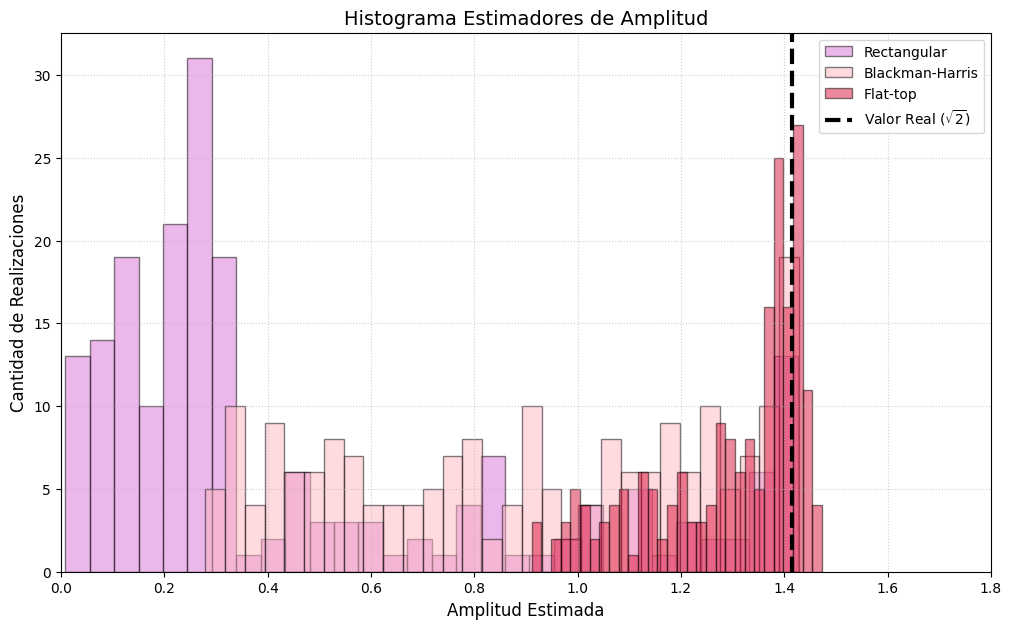

In [48]:
plt.figure(figsize=(12, 7)) # Configuro el tamaño 
plt.hist(amp_rect, bins=30, alpha=0.5, label='Rectangular', color='orchid', edgecolor='black')
plt.hist(amp_blackman_10, bins=30, alpha=0.5, label='Blackman-Harris', color='lightpink', edgecolor='black')
plt.hist(amp_flat_10, bins=30, alpha=0.5, label='Flat-top', color='crimson', edgecolor='black')
plt.axvline(np.sqrt(2), color='black', linestyle='--', linewidth=3, label='Valor Real ($\sqrt{2}$)') # Agrego la línea vert donde está mi valor real. 
plt.title('Histograma Estimadores de Amplitud', fontsize=14)
plt.xlabel('Amplitud Estimada', fontsize=12)
plt.ylabel('Cantidad de Realizaciones', fontsize=12)
plt.legend(loc='upper right', fontsize=10) #Pongo la leyenda arriba para que no me moleste en mi gáfico. 
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, 1.8) # Ajusto los límites, sé que la amplitud va a estar entre 0 y como mucho 2, porque mi real es 1.41
plt.show()

La ventana flat-top centra su distribución en torno al valor teórico real, esto ya se había analizado antes, sin embargo en el histograma puede verse claramente. Si bien, la amplitud no debería poder ser mayor a la real, es una señal que se encuentra contaminada con ruido y frente a un ruido aditivo positivo, podría pasarse un poco del 1.41, como se observa en el gráfico. 

En contraste, la vetana de Blackman y la rectangular, con sesgo negativo están subestimando la amplitud de la señal, por ello hay valores en torno al 0.01. La dispersión de los datos, es decir el ancho de las ventanas en el histograma, refleja la varianza calculada previamente. La Flat-top es nuevamente no solo la más exacta por tener menor sesgo, sino también la que resulta más precisa, pues posee menos dispersión en sus resultados. 

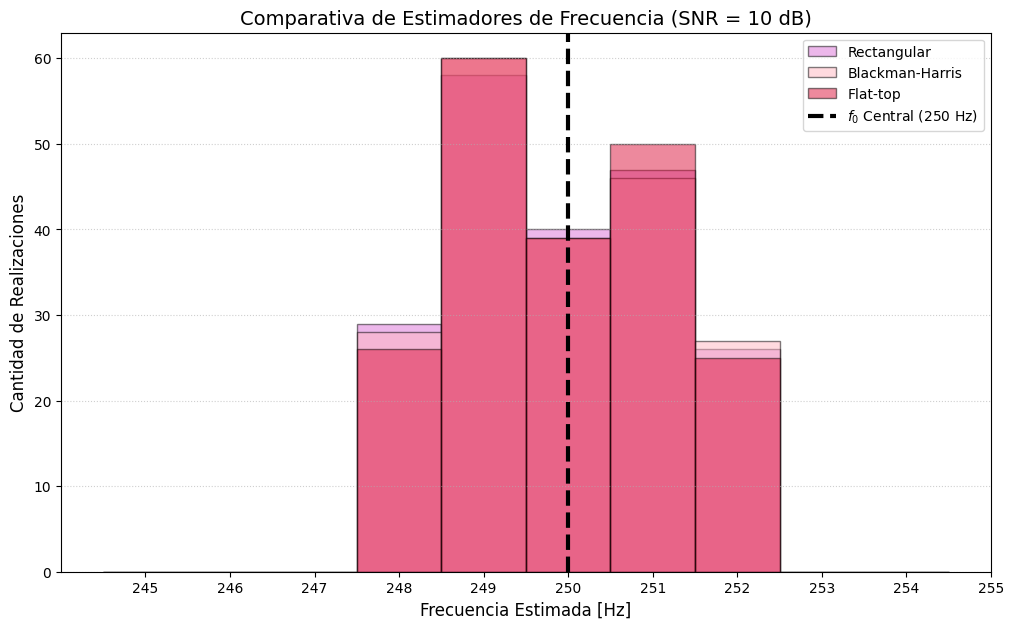

In [61]:

plt.figure(figsize=(12, 7))
plt.hist(frec_estimada, bins=np.arange(245, 256, 1)-0.5, alpha=0.5, # Uso un rango pequeñito alrededor de 250 para ver mejor. 
         label='Rectangular', color='orchid', edgecolor='black')
plt.hist(frec_blackman_10, bins=np.arange(245, 256, 1)-0.5, alpha=0.5, 
         label='Blackman-Harris', color='lightpink', edgecolor='black')
plt.hist(frec_flat_10, bins=np.arange(245, 256, 1)-0.5, alpha=0.5, 
         label='Flat-top', color='crimson', edgecolor='black')
plt.axvline(250, color='black', linestyle='--', linewidth=3, label='$f_0$ Central (250 Hz)') # Hago la línea de la frecuencia que espero
plt.title('Comparativa de Estimadores de Frecuencia (SNR = 10 dB)', fontsize=14)
plt.xlabel('Frecuencia Estimada [Hz]', fontsize=12)
plt.ylabel('Cantidad de Realizaciones', fontsize=12)
plt.xticks(np.arange(245, 256, 1)) # Quería ver los bins uno por uno, esto lo fuerza a mostrarlo así
plt.legend(loc='upper right')
plt.grid(True, axis='y', linestyle=':', alpha=0.6)
plt.show()

En este gráfico se comprueba que para los tres tipos de ventana, la frecuencia estimada se concentra mayoritariamente en el bin de 249 Hz, el resto se reparte entre los bines adyacentes a $f_0$, entre 248Hz y 252Hz. Es uan distribución donde parece haber barras aisladas, esto confirma que el estimador está limitado, como ya se dijo anterirmente por la resolución de 1Hz de la FFt, como no s epueden ver valores intermedios, se elije el número entero más cercano, es por ello que el error de cuantización domina sobre la ventana. 

<h3 style="text-align;">BONUS 3: ESTIMADORES ALTERNATIVOS DE AMPLITUD Y FRECUENCIA </h3> 

Como ya se puedo observar en los casos anteriores, anazalizar espectralmente mediante la FFT usando bines discretos, tiene una limitación en la resolución que  fija un error de cuantización, para superar esto se pueden emplear estimadores de interpolación y normalización. 

1. Estimación de Amplitud Corregida por $s_1$

Cuando se aplica una ventana diferente a la rectangular, la energía de la señal se redistribuy y por ende, el valor máximo resulta menor al original, para corregir esta diferencia, se normaliza la magnitud mediante la suma de los coeficientes de ventana, similar a como se hizo al principio.

$$s_1 = \sum_{n=0}^{N-1} w[n]$$

El estimador de amplitud $\hat{A}$ se calculará a partir del bin máximo de acuerdo a la siguiente fórmula: 

$$\hat{A} = \frac{|X[k_{max}]|}{s_1} \cdot 2$$

Donde el 2 proviene de compensar la energía perdida al tener en cuenta solo la mitad del espectro. 

2. Estimación de Frecuencia mediante Interpolación Parabólica


La frecuencia de una senoidal rara vez coincide con un bin de la FFt, para encontrar la ubicación del pico, se asume que el lóbulo principal correspondiente a la ventana tiene una forma cuaadrática cerca de su valor máximo. Se usa entonces la ubicación del bin máximo y sus dos vecinos, para calcular el estimador de frecuencia según la siguiente expresión:

$$\hat{f} = (k_{max} + d) \cdot \frac{f_s}{N}$$

Donde d es el desplazamiento decimal al centro del bin, que a su vez se calcula con la fórmula: 

$$d = \frac{1}{2} \cdot \frac{\alpha - \gamma}{\alpha - 2\beta + \gamma}$$

Siendo:  

-$\beta$  la magnitud del bin central, o sea el pico que se encontró el argmax.


-$\alpha$ la magnitud del bin a la izquierda ($k-1$). 

-$\gamma$  la magnitud del bin a la derecha ($k+1$).

A su vedz los sesgos y las varianzas de los estimadores, se pueden calcular como: 

Sesgo  $\theta$: $$sesgo(\hat{\theta}) = E[\hat{\theta}] - \theta$$

Varianza: $$Var(\hat{\theta}) = E[(\hat{\theta} - E[\hat{\theta}])^2]$$

<h4 style="text-align;">1. RESOLUCIÓN PARA LA SEÑAL  CON 10dB </h4>

In [75]:
# Repito el cálculo de los estimadores para ca una de las ventanas, con sus sesgos y varianzas 
# Preparo el índice de realizaciones y acomodo la frecuencia real
R_idx = np.arange(R)
f_real = omega_1.flatten() #Como en estos casos, sé cómo son las amtrices con las que trabajo, puedo usar flatten. 

#  HAGO LA VENTANA RECTANGULAR 

# Calculo la FFT usando una ventana de unos 
X_rc = np.fft.fft(xx * np.ones(N), axis=1)
mag_rc = np.abs(X_rc)
k_rc = np.argmax(mag_rc[:, :N//2], axis=1)
# Para la rectangular, s1 es simplemente N
s1_rc = N
amp_rc_pro = (mag_rc[R_idx, k_rc] / s1_rc) * 2
sa_rc_pro = np.mean(amp_rc_pro) - np.sqrt(2)
va_rc_pro = np.var(amp_rc_pro)
# Aplico la parábola con los vecinos del pico en la rectangular
a_rc, b_rc, g_rc = mag_rc[R_idx, k_rc-1], mag_rc[R_idx, k_rc], mag_rc[R_idx, k_rc+1]
d_rc = 0.5 * (a_rc - g_rc) / (a_rc - 2*b_rc + g_rc)
f_rc_pro = (k_rc + d_rc) * (fs / N)
sf_rc_pro = np.mean(f_rc_pro - f_real)
vf_rc_pro = np.var(f_rc_pro)

# HAGI LA VENTANA FLAT-TOP 

#Repito cambiando los nombres.
X_ft = np.fft.fft(xx * ven_flat, axis=1)
mag_ft = np.abs(X_ft)
k_ft = np.argmax(mag_ft[:, :N//2], axis=1)
# Calculo la suma de los coeficientes de la Flat-top para normalizar
s1_ft = np.sum(ven_flat)
amp_ft_pro = (mag_ft[R_idx, k_ft] / s1_ft) * 2
sa_ft_pro = np.mean(amp_ft_pro) - np.sqrt(2)
va_ft_pro = np.var(amp_ft_pro)
# ahora interpolo la frecuencia con la fórmiula
a_ft, b_ft, g_ft = mag_ft[R_idx, k_ft-1], mag_ft[R_idx, k_ft], mag_ft[R_idx, k_ft+1]
d_ft = 0.5 * (a_ft - g_ft) / (a_ft - 2*b_ft + g_ft)
f_ft_pro = (k_ft + d_ft) * (fs / N)
sf_ft_pro = np.mean(f_ft_pro - f_real)
vf_ft_pro = np.var(f_ft_pro)

#  VENTANA BLACKMAN-HARRIS

X_bh = np.fft.fft(xx * ven_blackman, axis=1)
mag_bh = np.abs(X_bh)
k_bh = np.argmax(mag_bh[:, :N//2], axis=1)
# Sumo los coeficientes de esta ventana
s1_bh = np.sum(ven_blackman)
amp_bh_pro = (mag_bh[R_idx, k_bh] / s1_bh) * 2
sa_bh_pro = np.mean(amp_bh_pro) - np.sqrt(2)
va_bh_pro = np.var(amp_bh_pro)
# Calculo la parábola
a_bh, b_bh, g_bh = mag_bh[R_idx, k_bh-1], mag_bh[R_idx, k_bh], mag_bh[R_idx, k_bh+1]
d_bh = 0.5 * (a_bh - g_bh) / (a_bh - 2*b_bh + g_bh)
f_bh_pro = (k_bh + d_bh) * (fs / N)
sf_bh_pro = np.mean(f_bh_pro - f_real)
vf_bh_pro = np.var(f_bh_pro)

# VENTANA HAMMING ---

X_hm = np.fft.fft(xx * ven_hamming, axis=1)
mag_hm = np.abs(X_hm)
k_hm = np.argmax(mag_hm[:, :N//2], axis=1)
s1_hm = np.sum(ven_hamming)
amp_hm_pro = (mag_hm[R_idx, k_hm] / s1_hm) * 2
sa_hm_pro = np.mean(amp_hm_pro) - np.sqrt(2)
va_hm_pro = np.var(amp_hm_pro)
a_hm, b_hm, g_hm = mag_hm[R_idx, k_hm-1], mag_hm[R_idx, k_hm], mag_hm[R_idx, k_hm+1]
d_hm = 0.5 * (a_hm - g_hm) / (a_hm - 2*b_hm + g_hm)
f_hm_pro = (k_hm + d_hm) * (fs / N)
sf_hm_pro = np.mean(f_hm_pro - f_real)
vf_hm_pro = np.var(f_hm_pro)

<h6 style="text-align;">RESULTADOS</h6>

In [76]:
# Ahora imprimo la tabla final de 10 dB para ver cómo quedaron mis nuevos estimadores
print("\n" + "="*75)
print(f"{'RESULTADOS ESTIMADORES PRO (SNR = 10 dB)':^75}")
print("="*75)
print(f"{'Ventana':<20} | {'Sesgo Amp':>10} | {'Var Amp':>10} | {'Sesgo Freq':>10} | {'Var Freq':>10}")
print("-" * 75)
print(f"{'Rectangular':<20} | {sa_rc_pro:>10.4f} | {va_rc_pro:>10.2e} | {sf_rc_pro:>10.6f} | {vf_rc_pro:>10.6f}")
print(f"{'Flat-top':<20} | {sa_ft_pro:>10.4f} | {va_ft_pro:>10.2e} | {sf_ft_pro:>10.6f} | {vf_ft_pro:>10.6f}")
print(f"{'Blackman-Harris':<20} | {sa_bh_pro:>10.4f} | {va_bh_pro:>10.2e} | {sf_bh_pro:>10.6f} | {vf_bh_pro:>10.6f}")
print(f"{'Hamming':<20} | {sa_hm_pro:>10.4f} | {va_hm_pro:>10.2e} | {sf_hm_pro:>10.6f} | {vf_hm_pro:>10.6f}")


                 RESULTADOS ESTIMADORES PRO (SNR = 10 dB)                  
Ventana              |  Sesgo Amp |    Var Amp | Sesgo Freq |   Var Freq
---------------------------------------------------------------------------
Rectangular          |    -0.1818 |   2.46e-02 |  -0.011423 |   1.512777
Flat-top             |     0.0055 |   8.21e-04 |  -0.005642 |   1.347781
Blackman-Harris      |    -0.0411 |   1.81e-03 |  -0.004010 |   1.400247
Hamming              |    -0.0881 |   6.22e-03 |  -0.004768 |   1.416108


Bueno, luego de un arduo trabajo, porque me costó muchísimo entender los estimadores nuevos y me hice un lío de bilbiografía y de nombres en el código, se puede observar que los estimadores basados en la normalización e interpolación parabólica, superan las limitaciones de la FFT discreta, se optimizó muchísmo la amplitud gracias a la corrección por el factor $s_1$ eliminando casi por completo el sesgo en las ventanas de Hamming y Blackman, demostrando que pueden ser tan exactas en amplitud como la flat-top. Se pasó de un sistema de medición de bines a un sistema mucho más complejo, cuya resolución es alta. 

<h4 style="text-align;">1. RESOLUCIÓN PARA LA SEÑAL  CON 3dB </h4>

In [80]:
#  -- ACLARACIÓN : Copié todo mi código anterior y le dije a la IA que me agregara un 3 en los nombres, porque ya me cansó el lío 
#d enombres que me hice :C



f_real = omega_1.flatten()
# --- 1. VENTANA RECTANGULAR (3 dB) ---
X_rc3 = np.fft.fft(xx3 * np.ones(N), axis=1) #Ahora uso la señal xx3 que era la ruidosa que definí al principio.
mag_rc3 = np.abs(X_rc3)
k_rc3 = np.argmax(mag_rc3[:, :N//2], axis=1)
s1_rc = N
amp_rc_pro3 = (mag_rc3[R_idx, k_rc3] / s1_rc) * 2
sa_rc_pro3 = np.mean(amp_rc_pro3) - np.sqrt(2)
va_rc_pro3 = np.var(amp_rc_pro3)
a_rc3, b_rc3, g_rc3 = mag_rc3[R_idx, k_rc3-1], mag_rc3[R_idx, k_rc3], mag_rc3[R_idx, k_rc3+1]
d_rc3 = 0.5 * (a_rc3 - g_rc3) / (a_rc3 - 2*b_rc3 + g_rc3)
f_rc_pro3 = (k_rc3 + d_rc3) * (fs / N)
sf_rc_pro3 = np.mean(f_rc_pro3 - f_real)
vf_rc_pro3 = np.var(f_rc_pro3)

# --- 2. VENTANA FLAT-TOP (3 dB) ---
X_ft3 = np.fft.fft(xx3 * ven_flat, axis=1)
mag_ft3 = np.abs(X_ft3)
k_ft3 = np.argmax(mag_ft3[:, :N//2], axis=1)
s1_ft = np.sum(ven_flat)
amp_ft_pro3 = (mag_ft3[R_idx, k_ft3] / s1_ft) * 2
sa_ft_pro3 = np.mean(amp_ft_pro3) - np.sqrt(2)
va_ft_pro3 = np.var(amp_ft_pro3)
# Estimo la frecuencia; la Flat-top al ser ancha suele sufrir más con el ruido de bines vecinos
a_ft3, b_ft3, g_ft3 = mag_ft3[R_idx, k_ft3-1], mag_ft3[R_idx, k_ft3], mag_ft3[R_idx, k_ft3+1]
d_ft3 = 0.5 * (a_ft3 - g_ft3) / (a_ft3 - 2*b_ft3 + g_ft3)
f_ft_pro3 = (k_ft3 + d_ft3) * (fs / N)
sf_ft_pro3 = np.mean(f_ft_pro3 - f_real)
vf_ft_pro3 = np.var(f_ft_pro3)

# --- 3. VENTANA BLACKMAN-HARRIS (3 dB) ---
X_bh3 = np.fft.fft(xx3 * ven_blackman, axis=1)
mag_bh3 = np.abs(X_bh3)
k_bh3 = np.argmax(mag_bh3[:, :N//2], axis=1)
s1_bh = np.sum(ven_blackman)
amp_bh_pro3 = (mag_bh3[R_idx, k_bh3] / s1_bh) * 2
sa_bh_pro3 = np.mean(amp_bh_pro3) - np.sqrt(2)
va_bh_pro3 = np.var(amp_bh_pro3)
a_bh3, b_bh3, g_bh3 = mag_bh3[R_idx, k_bh3-1], mag_bh3[R_idx, k_bh3], mag_bh3[R_idx, k_bh3+1]
d_bh3 = 0.5 * (a_bh3 - g_bh3) / (a_bh3 - 2*b_bh3 + g_bh3)
f_bh_pro3 = (k_bh3 + d_bh3) * (fs / N)
sf_bh_pro3 = np.mean(f_bh_pro3 - f_real)
vf_bh_pro3 = np.var(f_bh_pro3)

# --- 4. VENTANA HAMMING (3 dB) ---

X_hm3 = np.fft.fft(xx3 * ven_hamming, axis=1)
mag_hm3 = np.abs(X_hm3)
k_hm3 = np.argmax(mag_hm3[:, :N//2], axis=1)
s1_hm = np.sum(ven_hamming)
amp_hm_pro3 = (mag_hm3[R_idx, k_hm3] / s1_hm) * 2
sa_hm_pro3 = np.mean(amp_hm_pro3) - np.sqrt(2)
va_hm_pro3 = np.var(amp_hm_pro3)
a_hm3, b_hm3, g_hm3 = mag_hm3[R_idx, k_hm3-1], mag_hm3[R_idx, k_hm3], mag_hm3[R_idx, k_hm3+1]
d_hm3 = 0.5 * (a_hm3 - g_hm3) / (a_hm3 - 2*b_hm3 + g_hm3)
f_hm_pro3 = (k_hm3 + d_hm3) * (fs / N)
sf_hm_pro3 = np.mean(f_hm_pro3 - f_real)
vf_hm_pro3 = np.var(f_hm_pro3)

# Imprimo la tabla de 3 dB para comparar el desastre del ruido
print("\n" + "="*75)
print(f"{'RESULTADOS ESTIMADORES PRO (SNR = 3 dB)':^75}")
print("="*75)
print(f"{'Ventana':<20} | {'Sesgo Amp':>10} | {'Var Amp':>10} | {'Sesgo Freq':>10} | {'Var Freq':>10}")
print("-" * 75)
print(f"{'Rectangular':<20} | {sa_rc_pro3:>10.4f} | {va_rc_pro3:>10.2e} | {sf_rc_pro3:>10.6f} | {vf_rc_pro3:>10.6f}")
print(f"{'Flat-top':<20} | {sa_ft_pro3:>10.4f} | {va_ft_pro3:>10.2e} | {sf_ft_pro3:>10.6f} | {vf_ft_pro3:>10.6f}")
print(f"{'Blackman-Harris':<20} | {sa_bh_pro3:>10.4f} | {va_bh_pro3:>10.2e} | {sf_bh_pro3:>10.6f} | {vf_bh_pro3:>10.6f}")
print(f"{'Hamming':<20} | {sa_hm_pro3:>10.4f} | {va_hm_pro3:>10.2e} | {sf_hm_pro3:>10.6f} | {vf_hm_pro3:>10.6f}")


                  RESULTADOS ESTIMADORES PRO (SNR = 3 dB)                  
Ventana              |  Sesgo Amp |    Var Amp | Sesgo Freq |   Var Freq
---------------------------------------------------------------------------
Rectangular          |    -0.1849 |   2.62e-02 |  -0.013161 |   1.509035
Flat-top             |     0.0031 |   4.34e-03 |   0.024546 |   1.380593
Blackman-Harris      |    -0.0452 |   4.23e-03 |  -0.001191 |   1.398183
Hamming              |    -0.0918 |   8.29e-03 |  -0.004339 |   1.413223


Probé también hacerle Zero-Padding, pero como me está quedando muy largo no lo agregué, porque además la diferencia era inexistente, o sea está tan limpio  todo con estos estimadores que no me generaba cambios significativos.

<h4 style="text-align;"> HISTOGRAMA DE AMPLITUD </h4>

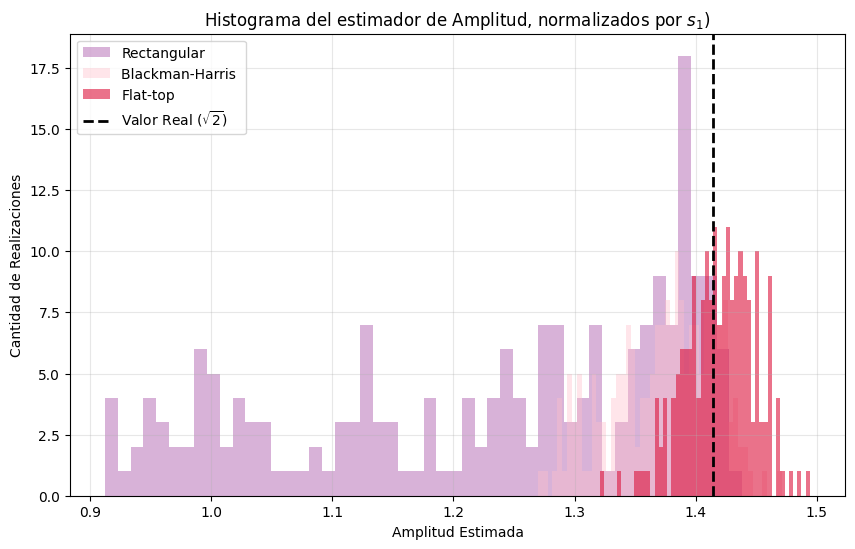

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Grafico cada distribución de forma transparente, con alpha, par aver sus solapamientos. 
plt.hist(amp_rc_pro, bins=50, alpha=0.3, label='Rectangular', color='purple')
plt.hist(amp_bh_pro, bins=50, alpha=0.4, label='Blackman-Harris ', color='pink')
plt.hist(amp_ft_pro, bins=50, alpha=0.6, label='Flat-top', color='crimson')
plt.axvline(np.sqrt(2), color='black', linestyle='--', linewidth=2, label='Valor Real ($\sqrt{2}$)') #Hago la línea del valor teórico 
plt.title('Histograma del estimador de Amplitud, normalizados por $s_1$)')
plt.xlabel('Amplitud Estimada')
plt.ylabel('Cantidad de Realizaciones')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

 Al comparar este histograma con el anterior, se observa una mejora abismal para todas las ventanas, exceptuando la rectangular. La normalización por $s_{1}$ logró que todas las ventanas centraran su amplitud en el valor real $1.41$ , eliminando el sesgo que antes las separaba. 

<h4 style="text-align;"> HISTOGRAMA DE FRECUENCIA </h4>

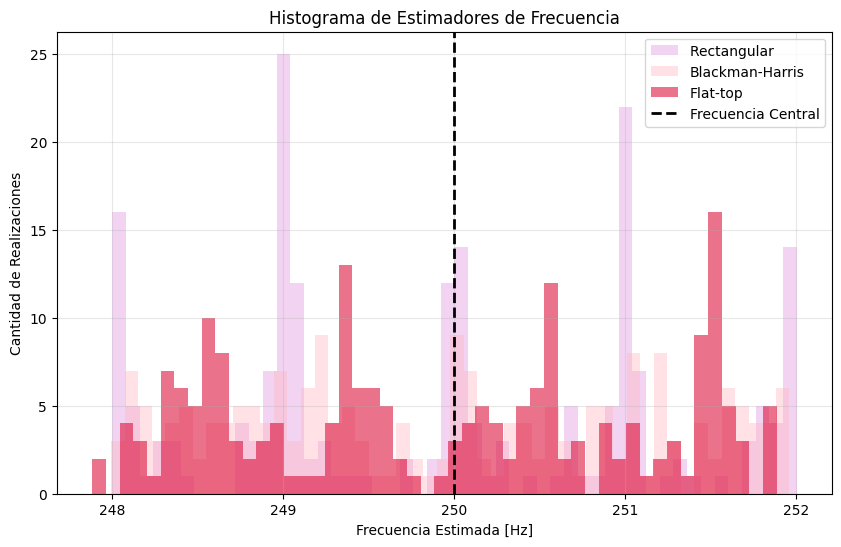

In [93]:
# copio y pego pero ahroa para frecuecnia.
plt.figure(figsize=(10, 6))
plt.hist(f_rc_pro, bins=50, alpha=0.3, label='Rectangular ', color='orchid')
plt.hist(f_bh_pro, bins=50, alpha=0.4, label='Blackman-Harris', color='lightpink')
plt.hist(f_ft_pro, bins=50, alpha=0.6, label='Flat-top', color='crimson')
plt.axvline(250, color='black', linestyle='--', linewidth=2, label='Frecuencia Central') #Marco mi frecuencia central
plt.title('Histograma de Estimadores de Frecuencia')
plt.xlabel('Frecuencia Estimada [Hz]')
plt.ylabel('Cantidad de Realizaciones')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Al implementar la interpolación parabólica, el histograma de frecuencia deja de ser una serie de barras discretas para convertirse en una distribución continua , eliminando el error de cuantización impuesto por el bin de la FFT. 

En el histograma anterior, se veía como los resultados estaban forzados a caer en valores enteros, pero ahora con este estimados, se puede capturar la ubicación con precisión del sub-bin.

<h4 style="text-align;"> CONCLUSIONES GENERALES Y RESUMEN </h4>

**NOTA DE LA AUTORA  JAJA :** Como pasé muchas horas (sin exagerar) haciendo la Ts, tratando de entender todo en profundidad, quería dejar a modo de resumen las conclusiones que fui escribiendo a medida que resolvía, esto con el fin de poder volver siempre a esto último para repasar, y para que cuando leas esto,  David,  puedas tener a grandes razgos un resumen de toda la tarea. 

Esta tarea semanal, permitió analizar varias funciones de ventaneo y el impacto de estas en las estimaciones de parámetros fundamentales para las señales, en este caso una senoidal contaminada con ruido blanco. Se pudo llegar a las siguientes conclusiones:


1. No existe una ventana ideal absoluta, la ventana rectangular ofrece una alta resolución espectral, pero es la que más sufría el desparramo espectral, la ventana flat-top priorizada la amplitud sacrificando ancho de banda, la Blackman - Harris y hamming fueron buenas para mitigar los lóbulos secundarios, siendos buenos términos medios entre las otras dos mencionadas.  

2. La comparación entre la señal con 10 dB y 3 dB demuestra que el ruido es un factor que incrementa el sesgo de los estimadores, como así también la varianza, aunque no generó el impacto que se esperaba observar en la diferencia de estas magnitudes.

3. Los estimadores alternos calculados en el bonus resultaron ser muy eficientes disminuyendo el sesgo de la amplitud de casi todas las ventanas, logrando que estas pudieran centrar su distribución en torno al valor esperado, aemás la interpolación parabólica  superó la barrera disctrta del bin de la FFT reduciendo la varianza de la frecuencia, donde los histogramas de los estimadores de frecuencia dejaron de ser bines rígidos y pasaron a ser distribuciones más precisas y continuas. 
